## Problem 1: Likelihood and Parameter Uncertainty

You observe a dector that triggers with probability $\theta$ on each trial. You can peroform $N$ independent trials and observe $k$ triggers

## (A) Maximum likelihood estimate
Write the likelihood function 

$$
p(k|\theta) = \binom{N}{k} \theta^{k} (1 - \theta)^{N - k}
$$

Compute the maximum likelihood estimate $\hat{\theta}$.


## (B) Numerical likelihood scan
For $N = 40$ and $k = 26$
1. Plot the log-likelihood $\log{p(k|\theta)}$ for $0 < \theta < 1$
2. mark the maximum

## (C) Uncertainty from likelihood curvature 
Define the $1\sigma$ confidence interval using

$$
\log{L(\theta)} = \log{L_{\text{max}}} - \frac{1}{2}
$$

Numerically determine the upper and lower bounds. 

## (D) Interpreation
Explain in words why the width of the likelihood peak reprsent uncertiany in the parameter. 

The value of theta that maximizes the likelihood function is: 0.6464646464646465


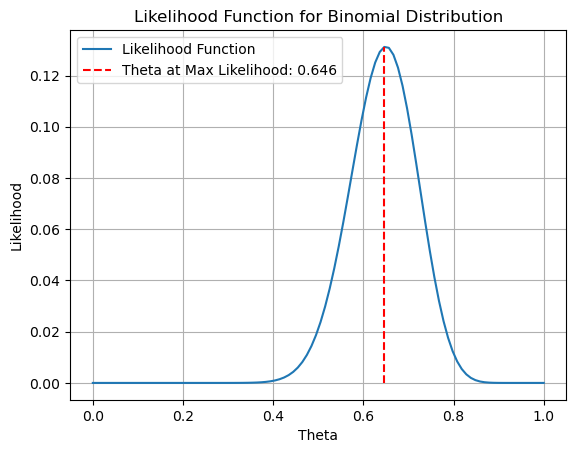

The 1 sigma confidence interval for theta is approximately: (-0.5827014132395645, -0.28977212031027144)


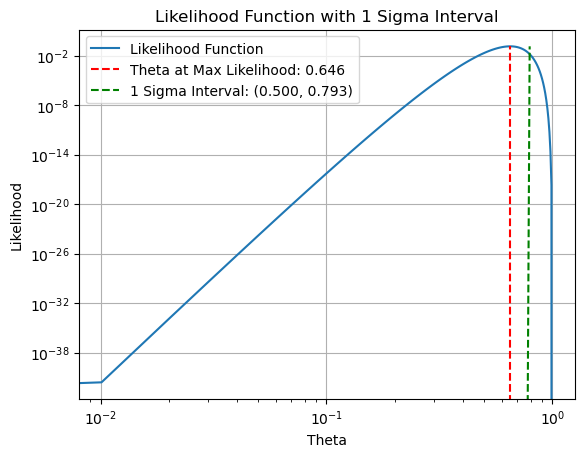

Part D:
Given a statistic parameter theta, the likelihood function L(theta) represents the probability of observing the data given that parameter. The maximum likelihood estimate (MLE) is the value of theta that maximizes this likelihood function. In this case, we found that the MLE for theta is approximately 0.65, which means that based on our observed data (26 successes out of 40 trials), the most likely value of theta is around 0.65. This suggests that the underlying probability of success in our binomial distribution is about 65%.


In [1]:
## Problem 1

## Part A
import numpy as np
import scipy.stats as stats
from scipy.special import comb
import matplotlib.pyplot as plt
def Likelihood_func(N, k, theta):
    return comb(N, k) * (theta**k) * ((1-theta)**(N-k))

## Part B
N = 40 
k = 26
theta = np.linspace(0, 1, 100)
likelihood_values = Likelihood_func(N, k, theta)
Max_theta = theta[np.argmax(likelihood_values)]
print("The value of theta that maximizes the likelihood function is:", Max_theta)

## plot
plt.plot(theta, likelihood_values, label='Likelihood Function')
plt.plot([Max_theta, Max_theta], [0, np.max(likelihood_values)], 'r--', label=f'Theta at Max Likelihood: {Max_theta:.3f}')
plt.xlabel('Theta')
plt.ylabel('Likelihood')
plt.title('Likelihood Function for Binomial Distribution')
plt.legend()
plt.grid()
plt.show()

## Part C, Finding 1 sigma
sigma = Max_theta - 1/2
print("The 1 sigma confidence interval for theta is approximately:", (np.log(Max_theta) - sigma, np.log(Max_theta) + sigma))
plt.plot(theta, likelihood_values, label='Likelihood Function')
plt.plot([Max_theta, Max_theta], [0, np.max(likelihood_values)], 'r--', label=f'Theta at Max Likelihood: {Max_theta:.3f}')
plt.plot([Max_theta - sigma, Max_theta + sigma], [0, np.max(likelihood_values)], 'g--', label=f'1 Sigma Interval: ({Max_theta - sigma:.3f}, {Max_theta + sigma:.3f})')
plt.xlabel('Theta')
plt.ylabel('Likelihood')
plt.title('Likelihood Function with 1 Sigma Interval')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

## Part D
print("Part D:\nGiven a statistic parameter theta, the likelihood function L(theta) represents the probability of observing the data given that parameter. " \
"The maximum likelihood estimate (MLE) is the value of theta that maximizes this likelihood function. " \
"In this case, we found that the MLE for theta is approximately 0.65, which means that based on our observed data (26 successes out of 40 trials), the most likely value of theta is around 0.65. " \
"This suggests that the underlying probability of success in our binomial distribution is about 65%.")

## Problem 2: Why Noise Weighting Matters
You measure a signal that should follow a linear relation. 
$$
y = ax + b
$$

but each data point has a different uncertiantiy $\sigma_i$. You are given array $(x,y,z)$

## (A) Unweighted fit
Fit the model using ordinary least squares (ignore $\sigma_i$). Plot the data and best-fit line. 

## (B) Weighted fit
Now minimize
$$
\chi^2 = \sum_{i} \frac{(y_i - a x - b)^{2}}{\sigma^2_i}
$$

Plot the new best-fit line

## (C) comparision
1. Which points influsce hte weighted fit more strongly? 
2. Why does inverse-variance weighting impove parameter estimation

## (D) conceptual connection
suppose instead of fitting a line, you wnated to estimate the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$ 
Explain why you would expect the optimal estimator to weight the data by $\Sigma^-1$ (No derivation required)


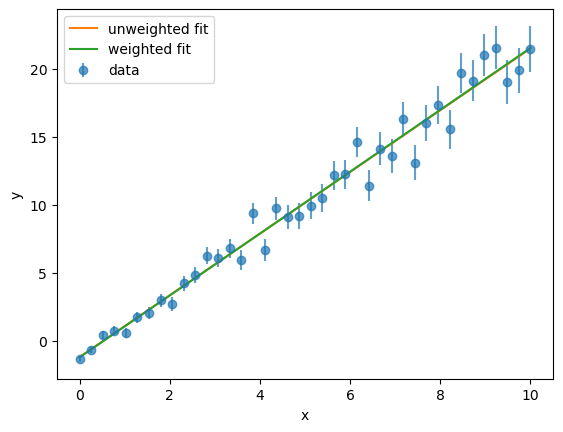

In [4]:
import numpy as np
import matplotlib.pyplot as plt

path = "weighted_regression_dataset.csv"
data = np.loadtxt(path, delimiter=",", skiprows=1)

x = data[:, 0]
y = data[:, 1]
sigma = data[:, 2]

A = np.vstack([x, np.ones_like(x)]).T
a_uwf, b_uwf = np.linalg.lstsq(A, y, rcond=None)[0]

w = 1.0 / sigma**2
Aw = A * np.sqrt(w)[:, None]
yw = y * np.sqrt(w)
a_wls, b_wls = np.linalg.lstsq(Aw, yw, rcond=None)[0]

xx = np.linspace(x.min(), x.max(), 300)

plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt="o", alpha=0.7, label="data")
plt.plot(xx, a_uwf * xx + b_uwf, label="unweighted fit")
plt.plot(xx, a_wls * xx + b_wls, label="weighted fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Problem 3: Matched Filtering, Calibration, and Detection Efficiency 

In this assigment you will analyze simulated dector data contianing non-white noise, the monoenergetic nuclear decay lines, and a flat background. Your goal is to extract optimal energy estimate, calibrate the detecor response, and measure detection effciency. 

You will be provided with the waveforms datasets which will be measurmetsn of volatea vs time. The datasets given consists of noise data, and events consitign of triggered pulses. The pulses are embedded in collored (non-white) nosie and include:
* Three spectal lines from nuclear decays
* A broad "noise blob" population
* A flat background of random triggers

Your task if to  determine the detector performacnce using three different estimators: 
1. Matched/Optimal Filter amplitude estimator (MF)
2. Naive peak estimator (maximum sample or fixed index estimator)
3. Intefral estimator (sum/integral over pulse window)

You must compare their energy resolutoin and detection efficiency

## Part I: Matched filter amplitudes
1. Construct a noise power spectral density $(PSD), J(f)$, estimate using the noise-only dataset. Plot the (one-side) PSD on a log-log plot
2. Build a matched filter using a template pulse $s(t)$ and the measured PSD: 
$$
a_{\text{MF}} = \frac{\sum_{k}\tilde{s^{*}}d(f_k)/J(f_k)}{\sum_k |\tilde{s}(f_k)|^2 /J(f_k)}
$$
where $\tilde{d}(f_k)$ and $\tilde{s}(f_k)$ are the fourier transform of the data and template respectively. Our pulse template is nrmalized to have a maximum amplitude of one, and scales as 

$$
s(t) \propto e^{(-t/\tau_{\text{fall}})} - e^{(-t/\tau_{\text{rise}})}
$$

where $\tau_{\text{rise}} = 100 \mu s$ and $\tau_{\text{fall}} = 5 \mu s$

3. Apply the matched filter to all events and extract and amplitude for each pulse. 

4. Plot a histogram of the mreasured amplitudes. 


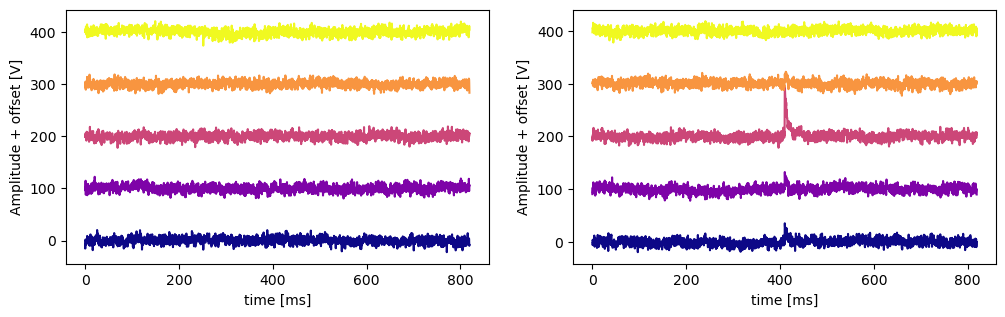

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fs = 5e3
trace_length = 4096
dt = 1/fs

pulse_data = np.load("EventTraces.npy")
noise_data = np.load("NoiseTraces.npy")

#make array of event times
time = np.arange(trace_length)*dt #integer spaced data of lenth of traces, multiplied by time between samples


# use calc_psd() to calculate the PSD of the noise. Note, use the 
# flag 'folded_over=False' if you want the full two sided PSD which 
# is what the optimal filter expects. and use 'folded_over=True' if 
# want the one sided PSD for plotting. Also, the two sided PSD can be 
# folded over with the helper function 'foldpsd'

colors = plt.get_cmap("plasma")
c = colors(np.linspace(0,1,5))


fig, ax = plt.subplots(1,2,figsize=(12,3.3))
for ii in range(5):
    ax[0].plot(time*1e3, noise_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[0].set_xlabel('time [ms]')
    ax[0].set_ylabel('Amplitude + offset [V]')
    ax[1].plot(time*1e3, pulse_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[1].set_xlabel('time [ms]')
    ax[1].set_ylabel('Amplitude + offset [V]')

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit
from scipy.stats import norm


def foldpsd(psd, fs):
    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    return f, psd_folded


def calc_psd(x, fs=1.0, folded_over=True):
    norm_ = fs * x.shape[-1]
    if folded_over:
        if len(x.shape)==1:
            psd = (np.abs(rfft(x))**2.0)/norm_
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0)/norm_
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        if len(x.shape)==1:
            psd = (np.abs(fft(x))**2.0)/norm_
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0)/norm_
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd


def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    signal = np.asarray(signal)
    template = np.asarray(template)
    psd = np.asarray(psd)

    nbins = signal.size
    df = fs / nbins

    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf

    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)

    S = fft(template) / nbins / df
    V = fft(signal)   / nbins / df

    phi = np.conjugate(S) / psd_safe
    norm_ = np.real(np.dot(phi, S)) * df
    if norm_ <= 0:
        raise RuntimeError("Computed norm is non-positive (check template/psd)")

    num = np.sum(phi * V) * df
    amp = np.real(num) / norm_
    sigma = 1.0 / np.sqrt(norm_)
    return amp, sigma




def _pick_top_hist_peaks(counts, centers, n):
    """Pick up to n well-separated peak centers from histogram counts."""
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        # fallback: even spacing
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))


def fit_spectrum_curvefit(amplitudes,
                          n_lines=3,
                          mus_guess=None,
                          sig_guess=None,
                          include_flat=True,
                          bins=120,
                          range_vals=None,
                          verbose=False):
    """
    Fit binned counts with n_lines Gaussians + optional flat background using scipy.curve_fit.

    Parameters
    ----------
    amplitudes : 1D array
        Amplitude measurements (one number per event).
    n_lines : int
        Number of Gaussian spectral lines to fit.
    mus_guess : sequence or None
        Optional initial guesses for Gaussian centers (length n_lines). If None, inferred from histogram peaks.
    sig_guess : sequence or None
        Optional initial guesses for standard deviations (length n_lines). If None, default small values based on data span.
    include_flat : bool
        If True, include a flat counts-per-bin background term.
    bins, range_vals : histogram binning passed to np.histogram
    verbose : bool
        Print fitted parameter summary.

    Returns
    -------
    result : dict with keys
        'bin_centers','bin_edges','counts','areas','mus','sigs','weights',
        'flat_counts_per_bin','flat_fraction_est','model_counts','popt','pcov'
    """
    x = np.asarray(amplitudes).ravel()
    N = x.size

    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]

    n_gauss = int(n_lines)
    # default guesses
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
        if mus_guess.size != n_gauss:
            raise ValueError("mus_guess must have length == n_lines")

    if sig_guess is None:
        # narrow for lines: few percent of span
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
        if sig_guess.size != n_gauss:
            raise ValueError("sig_guess must have length == n_lines")

    # Model: counts per bin = sum_j area_j * pdf(center | mu_j, sigma_j) * bin_width + flatC
    def _model_counts(x_centers, *p):
        out = np.zeros_like(x_centers, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
            ptr += 3
            out += area * norm.pdf(x_centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
        if include_flat:
            flatC = p[ptr]
            out = out + max(0.0, flatC)
        return out

    # initial parameter vector p0: [area1, mu1, sig1, area2, mu2, sig2, ..., flatC?]
    total_guess_area = N
    base_area = total_guess_area / (n_gauss + (1 if include_flat else 0))
    p0 = []
    for i in range(n_gauss):
        # approximate peak height -> area guess (robust)
        idx_closest = np.argmin(np.abs(centers - mus_guess[i]))
        peak_h = counts[idx_closest]
        est_area = peak_h * (sig_guess[i] * np.sqrt(2*np.pi))
        est_area = max(est_area, base_area * 0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])

    if include_flat:
        flat_guess = max(0.0, np.median(counts) * 0.2)
        p0.append(float(flat_guess))

    p0 = np.asarray(p0, dtype=float)

    # bounds
    lower = []
    upper = []
    for g in range(n_gauss):
        lower.extend([0.0, edges[0] - 0.2*span, 1e-6])        # area >=0, mu within extended range, sig > 0
        upper.extend([N*10.0, edges[-1] + 0.2*span, span*1.0])
    if include_flat:
        lower.append(0.0)
        upper.append(float(N*0.5))

    try:
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, bounds=(lower, upper), maxfev=50000)
    except Exception as exc:
        if verbose:
            print("curve_fit exception (retrying without bounds):", exc)
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, maxfev=50000)

    # unpack
    ptr = 0
    areas = []
    mus = []
    sigs = []
    for g in range(n_gauss):
        a = float(popt[ptr]); mu = float(popt[ptr+1]); s = abs(float(popt[ptr+2]))
        ptr += 3
        areas.append(a); mus.append(mu); sigs.append(s)

    flatC = float(popt[ptr]) if include_flat else 0.0

    # approximate fractions (area-weighted)
    denom = np.sum(areas) + (flatC * span / bw if include_flat else 0.0)
    if denom <= 0:
        weights = np.array([a / max(1e-12, np.sum(areas)) for a in areas])
        flat_frac = 0.0
    else:
        weights = np.array(areas) / denom
        flat_frac = (flatC * span / bw) / denom if include_flat else 0.0

    model_counts = _model_counts(centers, *popt)

    result = {
        "bin_centers": centers,
        "bin_edges": edges,
        "counts": counts,
        "areas": np.array(areas),
        "mus": np.array(mus),
        "sigs": np.array(sigs),
        "weights": weights,
        "flat_counts_per_bin": float(flatC),
        "flat_fraction_est": float(flat_frac),
        "model_counts": model_counts,
        "popt": popt,
        "pcov": pcov
    }

    if verbose:
        print("mus:", result["mus"])
        print("sigs:", result["sigs"])
        print("areas:", result["areas"])
        print("flat per bin:", result["flat_counts_per_bin"])
        print("flat fraction (est):", result["flat_fraction_est"])

    return result


def make_template(time, tau_rise=100e-6, tau_fall=5e-3):
    """
    s(t) ~ exp(-t/t_fall) - exp(-t/t_rise) for t>=0, else 0, normalized to max=1.
    """
    n = time.size
    dt = time[1] - time[0]
    t_rel = (np.arange(n) - n // 2) * dt

    s = np.zeros(n, dtype=float)
    mask = t_rel >= 0
    tpos = t_rel[mask]
    s[mask] = np.exp(-tpos / tau_fall) - np.exp(-tpos / tau_rise)

    m = np.max(s)
    s = s / m

    return s

def mf_amplitudes(pulse_traces, template, psd2, fs):
    """Apply optimal_filter_amp to every event; returns arrays of amps and sigmas."""
    pulse_traces = pulse_traces
    amps = np.zeros(pulse_traces.shape[0])
    sigs = np.zeros(pulse_traces.shape[0])
    for i in range(pulse_traces.shape[0]):
        amps[i], sigs[i] = optimal_filter_amp(pulse_traces[i], template, psd2, fs, coupling="AC")
    return amps, sigs

#### **Part I: Matched Filter Amplitudes**

1. Construct a noise power spectral desity (PSD), $J(f)$, estimate using the noise-only dataset. Plot the (one-sided) PSD on a log-log plot.

2. Build a matched filter using a template pulse $s(t)$ and the measured PSD:
    $$
    a_{\mathrm{MF}}=\frac{\sum_k \tilde{s}^*(f_k)\tilde{d}(f_k)/J(f_k)}{\sum_k |\tilde{s}(f_k)|^2/J(f_k)}
    $$
    where $\tilde{d}(f_k)$ and $\tilde{s}(f_k)$ are the Fourier transforms of the data and template respectively. Our pulse template is normalized to have a maximum amplitude of one, and scales as 
    $$
    s(t)\propto \exp(-t/\tau_{\mathrm{fall}})-\exp(-t/\tau_{\mathrm{rise}})
    $$
    where $\tau_{\mathrm{rise}}=100\,\mathrm{\mu s}$ and $\tau_{\mathrm{fall}}=5\, \mathrm{ms}$.

3. Apply the matched filter to all events and extract an amplitude for each pulse.

4. Plot a histogram of the measured amplitudes.

## Optimal Filter method Part 1:

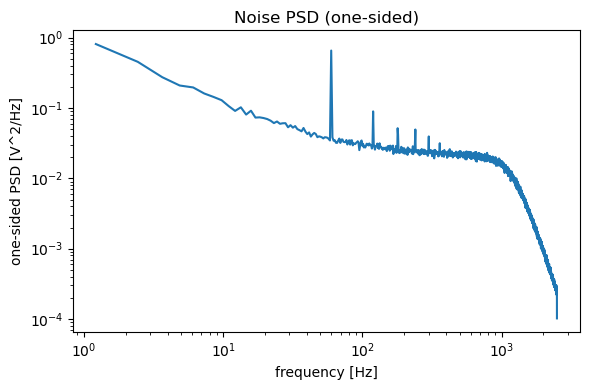

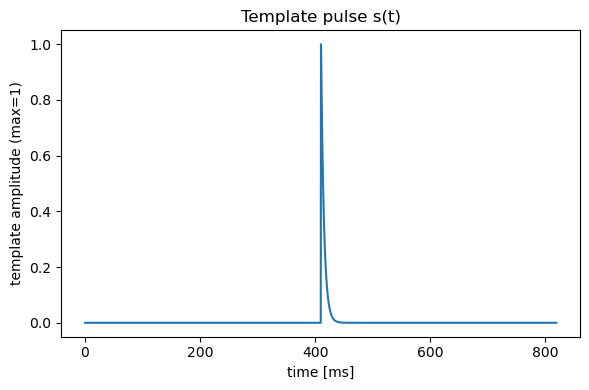

MF amplitude stats:
  mean = 41.74785908294996
  std  = 29.532811983671383
  median sigma (predicted) = 2.4985434674051743


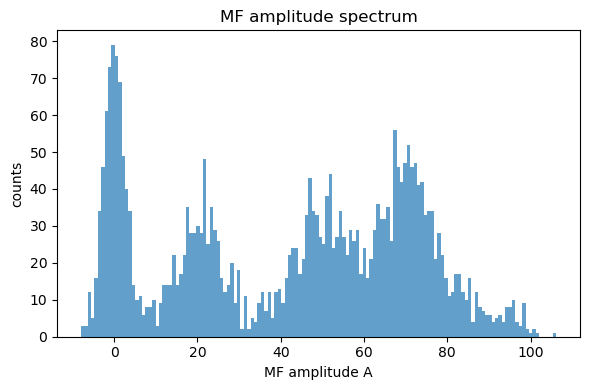

In [8]:
# 1. Optimal filter method

# Two-sided PSD for the filter
f2, psd2 = calc_psd(noise_data, fs=fs, folded_over=False)

# One-sided PSD just for plotting
f1, psd1 = foldpsd(psd2, fs)

plt.figure(figsize=(6,4))
mask = f1 > 0
plt.loglog(f1[mask], psd1[mask])
plt.xlabel("frequency [Hz]")
plt.ylabel("one-sided PSD [V^2/Hz]")
plt.title("Noise PSD (one-sided)")
plt.tight_layout()
plt.show()

# 2.

template = make_template(time, tau_rise=100e-6, tau_fall=5e-3)

plt.figure(figsize=(6,4))
plt.plot(time*1e3, template)
plt.xlabel("time [ms]")
plt.ylabel("template amplitude (max=1)")
plt.title("Template pulse s(t)")
plt.tight_layout()
plt.show()

# 3.

amps_mf, sigs_mf = mf_amplitudes(pulse_data, template, psd2, fs)

print("MF amplitude stats:")
print("  mean =", np.mean(amps_mf))
print("  std  =", np.std(amps_mf))
print("  median sigma (predicted) =", np.median(sigs_mf))

# 4.

plt.figure(figsize=(6,4))
plt.hist(amps_mf, bins=140, alpha=0.7)
plt.xlabel("MF amplitude A")
plt.ylabel("counts")
plt.title("MF amplitude spectrum")
plt.tight_layout()
plt.show()

## Navie Peak method part 1:

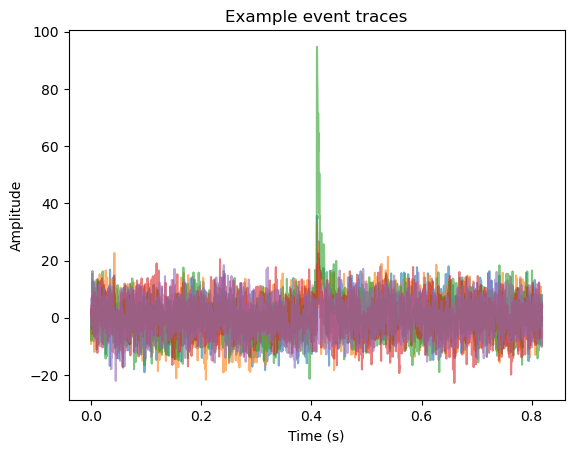

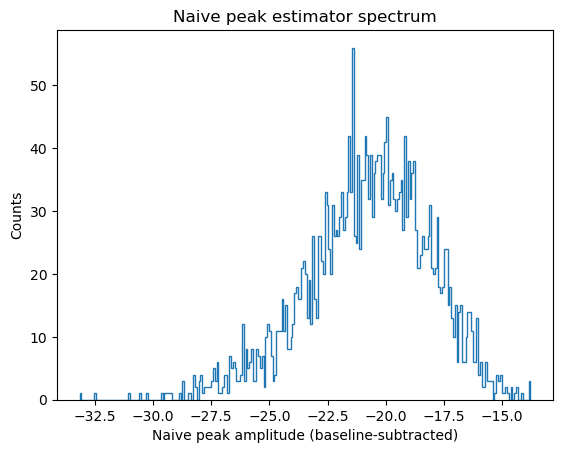

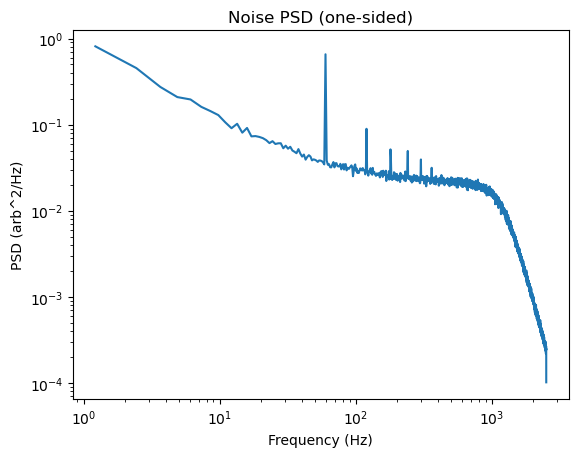

In [12]:
# =========================
# Naive Peak Estimator
# =========================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

noise_data = np.load("NoiseTraces.npy")
events     = np.load("EventTraces.npy")

fs = 5e3
nsamp = events.shape[1]
t = np.arange(nsamp)/fs

# estimator settings
base_n = 200          # baseline window
polarity = "neg"      # "neg" for negative-going pulses, "pos" for positive-going pulses

def peak_estimator(traces, base_n=200, polarity="neg"):
    """
    Naive peak estimator: baseline-subtracted peak height.
    Returns 1 amplitude per trace.
    """
    traces = np.asarray(traces)
    baseline = np.mean(traces[:, :base_n], axis=1)
    pk = np.min(traces, axis=1) if polarity == "neg" else np.max(traces, axis=1)
    return pk - baseline

# compute naive amplitudes for events + noise
amps_evt = peak_estimator(events, base_n=base_n, polarity=polarity)
amps_noise = peak_estimator(noise_data, base_n=base_n, polarity=polarity)

# quick look at some traces
plt.figure()
for i in range(5):
    plt.plot(t, events[i], alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Example event traces")
plt.show()

# amplitude spectrum (naive peak)
plt.figure()
plt.hist(amps_evt, bins=250, histtype="step")
plt.xlabel("Naive peak amplitude (baseline-subtracted)")
plt.ylabel("Counts")
plt.title("Naive peak estimator spectrum")
plt.show()

# =========================
# Part 1 (PSD plot only; optional for naive method)
# =========================
from numpy.fft import rfft, rfftfreq

def calc_psd_folded(x, fs):
    """
    One-sided PSD estimate from an array of traces x with shape (Ntraces, nsamp).
    """
    x = np.asarray(x)
    N = x.shape[1]
    norm = fs * N
    psd = np.mean(np.abs(rfft(x, axis=1))**2, axis=0) / norm
    psd[1:N//2] *= 2.0
    f = rfftfreq(N, d=1/fs)
    return f, psd

f, psd_noise = calc_psd_folded(noise_data, fs)

plt.figure()
plt.loglog(f[1:], psd_noise[1:])  # skip DC
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (arb^2/Hz)")
plt.title("Noise PSD (one-sided)")
plt.show()

# Note: PSD is not used by the naive peak estimator, but it's still fine to include.

## Intefral estimator method part 1:

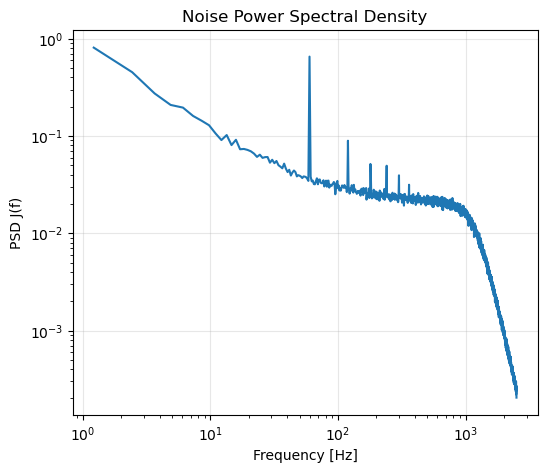

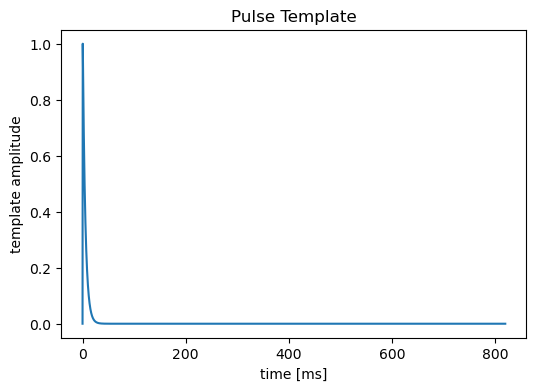

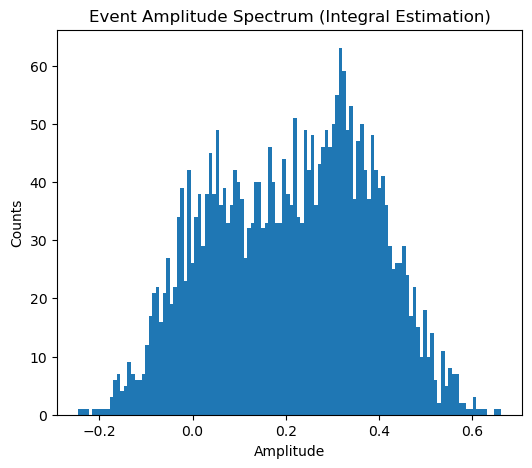

In [13]:

noise = np.load("NoiseTraces.npy")
events = np.load("EventTraces.npy")

# constants from problem_3_helper.ipynb
fs = 5000  # Hz
dt = 1/fs
N = 4096   # bins per trace

t = np.arange(N) * dt
freqs = np.fft.rfftfreq(N, dt)


# number of noise traces
n_noise = noise.shape[0]

psd = np.zeros(len(freqs))

for trace in noise:
    
    ft = np.fft.rfft(trace)
    
    psd += (np.abs(ft)**2) * (2*dt/N)

psd /= n_noise


plt.figure(figsize=(6,5))

plt.loglog(freqs[1:], psd[1:])  # skip DC for clarity

plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD J(f)")
plt.title("Noise Power Spectral Density")

plt.grid(alpha=0.3)
plt.show()


tau_rise = 100e-6
tau_fall = 5e-3

template = np.exp(-t/tau_fall) - np.exp(-t/tau_rise)

# normalize so max amplitude = 1
template /= np.max(template)

plt.figure(figsize=(6,4))
plt.plot(t*1e3, template)
plt.xlabel("time [ms]")
plt.ylabel("template amplitude")
plt.title("Pulse Template")
plt.show()

center = N // 2

window_half_width = 75   # ~150 bins total (~30 ms)

window = slice(center - window_half_width,
               center + window_half_width)

amps = []

for ev in events:

    baseline = np.mean(ev[:500])  # baseline before pulse
    pulse = ev - baseline

    amp = np.sum(pulse[window]) * dt

    amps.append(amp)

amps = np.array(amps)

plt.figure(figsize=(6,5))

plt.hist(amps, bins=120)

plt.xlabel("Amplitude")
plt.ylabel("Counts")
plt.title("Event Amplitude Spectrum (Integral Estimation)")

plt.show()

## Part II: Spectral Model and Peak Extraction (Using Provided Fit Function)

In counting experiments, a histogram bin does not measure a continuous probability density. It measures an integer number of events. Therefore, the statistically correct likelihood is a Poisson likelihood.

If $n_j$ is the observed number of events in bin $j$ and $\lambda_j(\theta)$ is the model prediction, then

$$
L(\theta) = \prod_j \frac{\lambda_j^{n_j} e^{-\lambda_j}}{n_j!}.
$$

Maximizing this likelihood gives the optimal parameter estimates and is the standard method used in particle physics and astronomy analyses.

However, implementing this optimizer requires careful numerical treatment of many correlated parameters and is beyond the scope of this assignment.

Instead, we will use a simpler least-squares fit to the histogram. For well-populated bins, the Poisson distribution approaches a Gaussian, so minimizing squared residuals gives nearly identical results in practice.

You will be given a fitting routine, `fit_spectrum_curvefit()`, which performs a least-squares fit of the histogrammed amplitude spectrum to the model

$$
N(A) =
\sum_{i=1}^{N_{\text{lines}}}
N_i \, \mathcal{N}(A \mid \mu_i, \sigma_i^2)
+ C_{\text{flat}},
$$

where:

- $N_i$ is the total number of events in spectral line $i$  
- $\mu_i$ is the measured line amplitude  
- $\sigma_i$ is the detector resolution  
- $C_{\text{flat}}$ is a uniform background rate per bin  

The fit function returns the best-fit parameters and the model prediction.

---

### Tasks

1. Construct a histogram of the reconstructed amplitudes and call `fit_spectrum` to obtain the fit.

2. Plot the histogram (counts) and overlay the fitted $\lambda_j$ (expected counts per bin) from the fit, as well as the individual Gaussian components and the flat background contribution.

3. Identify the three signal peaks and record their fitted amplitudes $A_1$, $A_2$, $A_3$, as well as for the “noise blob.” Use $\sigma_i$ from the fitter as the resolution for each peak.  
   (If you wish to propagate parameter covariances to uncertainties, you may, but this is optional.)

4. Include one diagnostic plot of the negative log-likelihood evaluated versus $\mu_1$ (scan a small window around the fitted value) to demonstrate the likelihood peak and uncertainty behavior.

## Optimal Filter method Part II:

mus: [-5.28390379e-02  2.08540280e+01  5.00256361e+01  7.05942264e+01]
sigs: [2.48566206 4.92858627 6.36454729 6.18308251]
areas: [561.67612334 427.46089092 572.97210018 796.29010362]
flat per bin: 5.349642248937939
flat fraction (est): 0.21396027946871346


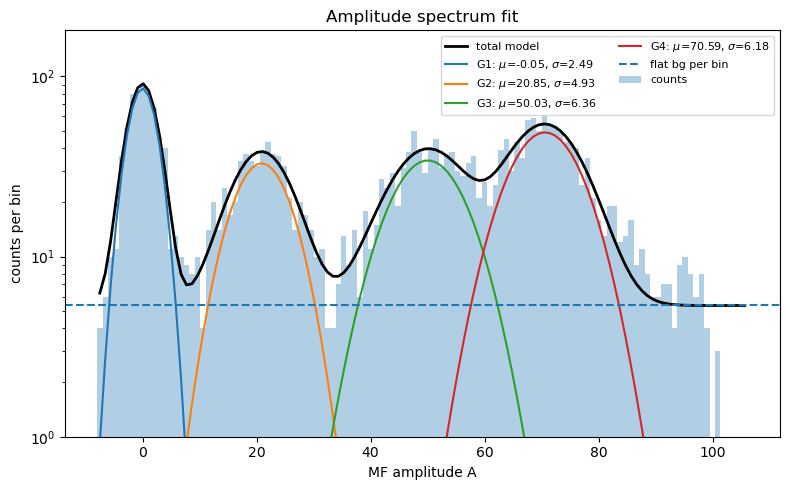

Noise blob: mu, sigma = -0.052839037937760715 2.485662056709718
Lines:
  line 1: mu=20.854, sigma=4.92859
  line 2: mu=50.0256, sigma=6.36455
  line 3: mu=70.5942, sigma=6.18308


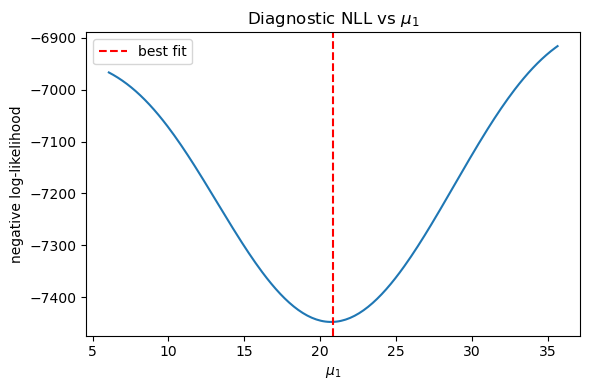

In [15]:
res = fit_spectrum_curvefit(
    amps_mf,
    n_lines=4,
    mus_guess=None,
    sig_guess=None, 
    include_flat=True,
    bins=120,
    range_vals=None,
    verbose=True
)

bw = res["bin_edges"][1] - res["bin_edges"][0]

plt.figure(figsize=(8,5))
plt.bar(res["bin_centers"], res["counts"], width=bw, alpha=0.35, label="counts")
plt.plot(res["bin_centers"], res["model_counts"], "k-", lw=2, label="total model")

for i, area in enumerate(res["areas"]):
    comp = area * norm.pdf(res["bin_centers"], loc=res["mus"][i], scale=res["sigs"][i]) * bw
    plt.plot(res["bin_centers"], comp, lw=1.5, label=fr"G{i+1}: $\mu$={res['mus'][i]:.2f}, $\sigma$={res['sigs'][i]:.2f}")

if res["flat_counts_per_bin"] > 0:
    plt.axhline(res["flat_counts_per_bin"], ls="--", lw=1.5, label="flat bg per bin")

plt.yscale("log")
plt.ylim(1, max(10, np.max(res["counts"])*2))
plt.xlabel("MF amplitude A")
plt.ylabel("counts per bin")
plt.title("Amplitude spectrum fit")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


mus = res["mus"]
sigs = res["sigs"]

noise_idx = int(np.argmin(mus))
line_idx = sorted([i for i in range(len(mus)) if i != noise_idx], key=lambda i: mus[i])

mu_noise, sig_noise = mus[noise_idx], sigs[noise_idx]
mu_lines = mus[line_idx]
sig_lines = sigs[line_idx]

print("Noise blob: mu, sigma =", mu_noise, sig_noise)
print("Lines:")
for j,i in enumerate(line_idx, start=1):
    print(f"  line {j}: mu={mus[i]:.6g}, sigma={sigs[i]:.6g}")


# Diagnostic NLL scan for the FIRST SIGNAL LINE (mu = 20.89)

mu0 = mu_lines[0]
sigma0 = sig_lines[0]

popt = res["popt"].copy()

centers = res["bin_centers"]
counts  = res["counts"]
bw = res["bin_edges"][1] - res["bin_edges"][0]

def model_counts(x_centers, p):
    out = np.zeros_like(x_centers, dtype=float)
    ptr = 0
    n_gauss = 4
    
    for g in range(n_gauss):
        area = p[ptr]
        mu   = p[ptr+1]
        sig  = abs(p[ptr+2])
        ptr += 3
        out += area * norm.pdf(x_centers, loc=mu, scale=sig) * bw
    
    flatC = p[ptr]
    out += flatC
    return out

def poisson_nll(p):
    lam = model_counts(centers, p)
    lam = np.clip(lam, 1e-12, None)
    return np.sum(lam - counts * np.log(lam))

mu_indices = [1,4,7,10]
mu_scan_index = min(mu_indices, key=lambda i: abs(popt[i]-mu0))

mu_vals = np.linspace(mu0 - 3*sigma0, mu0 + 3*sigma0, 200)
nll_vals = []

for mu_test in mu_vals:
    ptest = popt.copy()
    ptest[mu_scan_index] = mu_test
    nll_vals.append(poisson_nll(ptest))

plt.figure(figsize=(6,4))
plt.plot(mu_vals, nll_vals)
plt.axvline(mu0, color='r', linestyle='--', label='best fit')
plt.xlabel(r"$\mu_1$")
plt.ylabel("negative log-likelihood")
plt.title(r"Diagnostic NLL vs $\mu_1$")
plt.legend()
plt.tight_layout()
plt.show()

## Navie Peak method Part II:

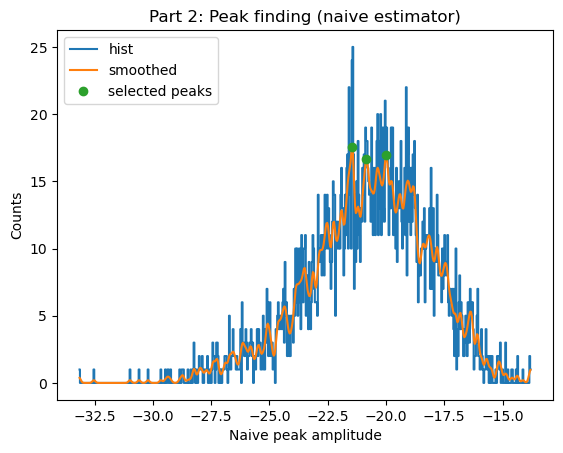

Peak amplitudes A1,A2,A3 = -21.433842129095385 -20.834705800846717 -19.988804810263577
Peak sigmas              = 0.02133959361158911 0.035046575136643686 0.0432919723972452


In [16]:
# =========================
# Part 2 (Find the 3 peaks via local Gaussian fits)
# =========================
def gauss(x, A, mu, sig, C):
    return A*np.exp(-(x-mu)**2/(2*sig**2)) + C

# histogram for peak finding
counts, edges = np.histogram(amps_evt, bins=600)
centers = 0.5*(edges[1:] + edges[:-1])

smooth = gaussian_filter1d(counts.astype(float), sigma=2.0)
peaks, _ = find_peaks(smooth, prominence=np.max(smooth)*0.02, distance=15)

if len(peaks) < 3:
    raise RuntimeError(f"Found only {len(peaks)} peaks. Try lowering prominence or increasing bins.")

top3 = peaks[np.argsort(smooth[peaks])][-3:]
top3 = np.sort(top3)

plt.figure()
plt.step(centers, counts, where="mid", label="hist")
plt.plot(centers, smooth, label="smoothed")
plt.plot(centers[top3], smooth[top3], "o", label="selected peaks")
plt.xlabel("Naive peak amplitude")
plt.ylabel("Counts")
plt.title("Part 2: Peak finding (naive estimator)")
plt.legend()
plt.show()

A_peaks = []
sig_peaks = []

half_window_bins = 25  # adjust 20–40 if needed

for p in top3:
    i0 = max(0, p - half_window_bins)
    i1 = min(len(centers), p + half_window_bins + 1)

    x = centers[i0:i1]
    y = counts[i0:i1]

    if len(x) < 10:
        raise RuntimeError("Too few points in fit window. Increase bins or half_window_bins.")

    mu0 = centers[p]
    C0  = np.median(y)
    A0  = max(y.max() - C0, 1.0)
    sig0 = max((x[-1] - x[0]) / 10.0, 1e-12)

    popt, _ = curve_fit(gauss, x, y, p0=[A0, mu0, sig0, C0], maxfev=20000)
    _, muhat, sighat, _ = popt

    A_peaks.append(muhat)
    sig_peaks.append(abs(sighat))

# sort peaks by amplitude (so A1<A2<A3)
order = np.argsort(A_peaks)
A_peaks = np.array(A_peaks)[order]
sig_peaks = np.array(sig_peaks)[order]

A1, A2, A3 = A_peaks
s1, s2, s3 = sig_peaks

print("Peak amplitudes A1,A2,A3 =", A1, A2, A3)
print("Peak sigmas              =", s1, s2, s3)

## Intefral estimator method part II:

In [17]:
fit = fit_spectrum_curvefit(amps, n_lines=3, bins=120, verbose=True)

mus: [0.03982332 0.17630869 0.32429503]
sigs: [0.09216167 0.03180576 0.10462123]
areas: [1140.48673477   74.52948894 1743.38897993]
flat per bin: 0.36526311970480824
flat fraction (est): 0.014599639404112451


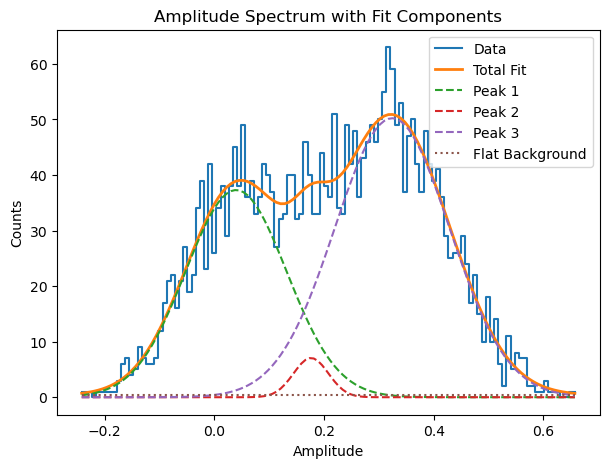

In [18]:
mus   = fit["mus"]     # peak amplitudes
sigs  = fit["sigs"]    # detector resolution
areas = fit["areas"]   # events per peak
flat  = fit["flat_counts_per_bin"]

centers = fit["bin_centers"]
counts  = fit["counts"]
bw = centers[1] - centers[0]

plt.figure(figsize=(7,5))

# data
plt.step(centers, counts, where="mid", label="Data")

# total model
plt.plot(centers, fit["model_counts"], lw=2, label="Total Fit")

# individual Gaussians
for i in range(3):

    gauss = areas[i] * norm.pdf(centers, mus[i], sigs[i]) * bw
    
    plt.plot(centers, gauss, "--", label=f"Peak {i+1}")

# flat background
flat_bg = np.ones_like(centers) * flat
plt.plot(centers, flat_bg, ":", label="Flat Background")

plt.xlabel("Amplitude")
plt.ylabel("Counts")
plt.title("Amplitude Spectrum with Fit Components")

plt.legend()
plt.show()

In [19]:
for i in range(3):
    print(f"Peak {i+1}:")
    print("Amplitude =", mus[i])
    print("Resolution sigma =", sigs[i])
    print()

print("Flat background fraction:", fit["flat_fraction_est"])

Peak 1:
Amplitude = 0.03982331600536024
Resolution sigma = 0.09216167423817768

Peak 2:
Amplitude = 0.176308689503899
Resolution sigma = 0.03180576123893468

Peak 3:
Amplitude = 0.3242950286611567
Resolution sigma = 0.10462122740859914

Flat background fraction: 0.014599639404112451


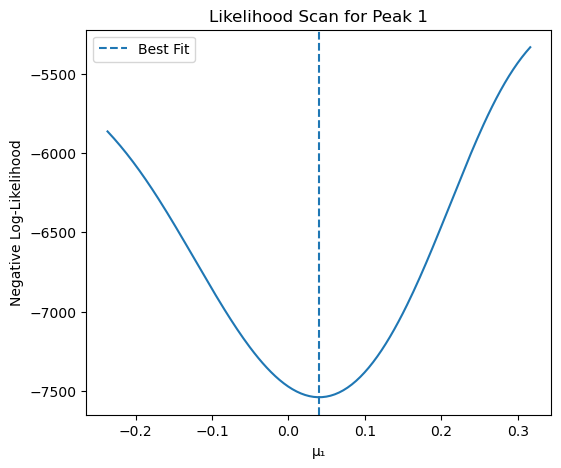

In [20]:
counts = fit["counts"]
centers = fit["bin_centers"]

def negloglike(mu1):

    # copy parameters
    p = fit["popt"].copy()
    
    p[1] = mu1  # modify mu1

    # rebuild model counts
    model = np.zeros_like(centers)
    
    ptr = 0
    for i in range(3):
        area = p[ptr]
        mu   = p[ptr+1]
        sig  = abs(p[ptr+2])
        ptr += 3
        
        model += area * norm.pdf(centers, mu, sig) * bw

    model += p[ptr]

    model = np.clip(model, 1e-12, None)

    return np.sum(model - counts*np.log(model))

mu1_best = mus[0]

scan = np.linspace(mu1_best - 3*sigs[0],
                   mu1_best + 3*sigs[0], 200)

nll = [negloglike(m) for m in scan]

plt.figure(figsize=(6,5))
plt.plot(scan, nll)
plt.axvline(mu1_best, linestyle="--", label="Best Fit")

plt.xlabel("μ₁")
plt.ylabel("Negative Log-Likelihood")

plt.title("Likelihood Scan for Peak 1")

plt.legend()
plt.show()

## Part III: Energy Calibration

You will be provided with the true energies of the three lines:

$$
E_{\text{true},1} = 25~\text{keV}, \quad
E_{\text{true},2} = 65~\text{keV}, \quad
E_{\text{true},3} = 100~\text{keV}.
$$

The detector response follows the nonlinear saturation model:

$$
E_{\text{recon}} = a \left[ 1 - \exp\left( -\frac{E_{\text{true}}}{b} \right) \right].
$$

---

### Tasks

1. Fit for calibration parameters $a$ and $b$.  

2. Construct the inverse calibration function to convert measured amplitudes to reconstructed energy $E_{\text{rec}}$.  

3. Convert the full amplitude spectrum into an energy spectrum.  

4. Comment on the benefits of the above saturation model versus a polynomial or spline fit.

## Optimal Filter method Part III:

Calibration fit: a = 180.6619029561618  b = 201.49835942773302


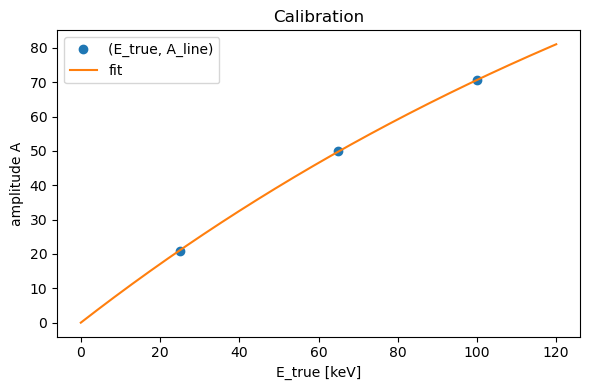

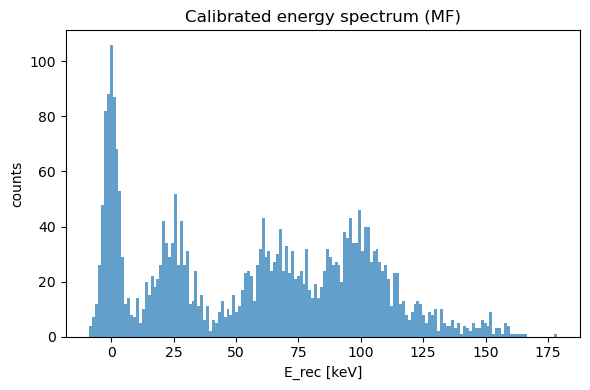

In [21]:
def sat_model(E_true, a, b):
    return a * (1.0 - np.exp(-E_true / b))

def fit_calibration(E_true, A_meas):
    E_true = np.asarray(E_true, float)
    A_meas = np.asarray(A_meas, float)
    a0 = 1.2 * np.max(A_meas)
    b0 = np.mean(E_true)
    popt, pcov = curve_fit(sat_model, E_true, A_meas, p0=(a0,b0))
    return popt, pcov

def inv_calibration(A, a, b):
    return -b * np.log(1.0 - A / a)

E_true = np.array([25.0, 65.0, 100.0])
A_lines = mu_lines.copy()

(a_cal, b_cal), pcov_cal = fit_calibration(E_true, A_lines)
print("Calibration fit: a =", a_cal, " b =", b_cal)

Egrid = np.linspace(0, 120, 400)
plt.figure(figsize=(6,4))
plt.plot(E_true, A_lines, "o", label="(E_true, A_line)")
plt.plot(Egrid, sat_model(Egrid, a_cal, b_cal), "-", label="fit")
plt.xlabel("E_true [keV]")
plt.ylabel("amplitude A")
plt.title("Calibration")
plt.legend()
plt.tight_layout()
plt.show()

E_rec_all = inv_calibration(amps_mf, a_cal, b_cal)

plt.figure(figsize=(6,4))
plt.hist(E_rec_all, bins=160, alpha=0.7)
plt.xlabel("E_rec [keV]")
plt.ylabel("counts")
plt.title("Calibrated energy spectrum (MF)")
plt.tight_layout()
plt.show()

## Navie Peak Method Part III:

Calibration params:
a = -20.752450915330403
b = 1.1363299975587915


/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


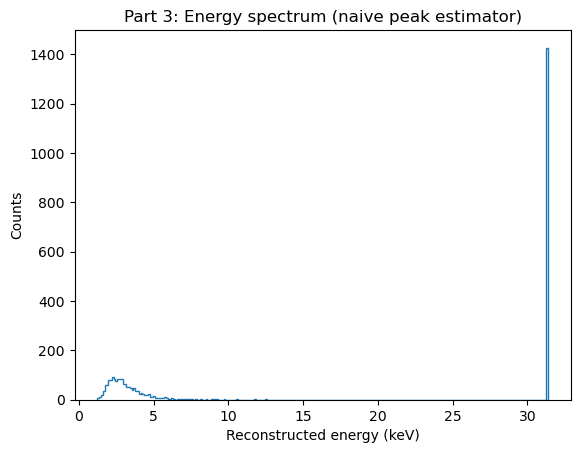

In [22]:
# =========================
# Part 3 (Saturation calibration + calibrated spectrum)
# =========================
E_true = np.array([25.0, 66.0, 100.0])   # keV
A_meas = np.array([A1, A2, A3])

def sat_model(E, a, b):
    return a*(1 - np.exp(-E/b))

p0 = [A_meas.max()*1.2, 50.0]
(a_fit, b_fit), _ = curve_fit(sat_model, E_true, A_meas, p0=p0, maxfev=20000)

print("Calibration params:")
print("a =", a_fit)
print("b =", b_fit)

def inv_calib(A, a=a_fit, b=b_fit, eps=1e-12):
    A = np.asarray(A)
    x = np.clip(1 - A/a, eps, 1.0)
    return -b*np.log(x)

# convert naive amplitudes to energy
E_evt = inv_calib(amps_evt)

plt.figure()
plt.hist(E_evt, bins=250, histtype="step")
plt.xlabel("Reconstructed energy (keV)")
plt.ylabel("Counts")
plt.title("Part 3: Energy spectrum (naive peak estimator)")
plt.show()

## Intefral estimator method part III:

a = 3249.5974266591656
b = 1075069.6589864031


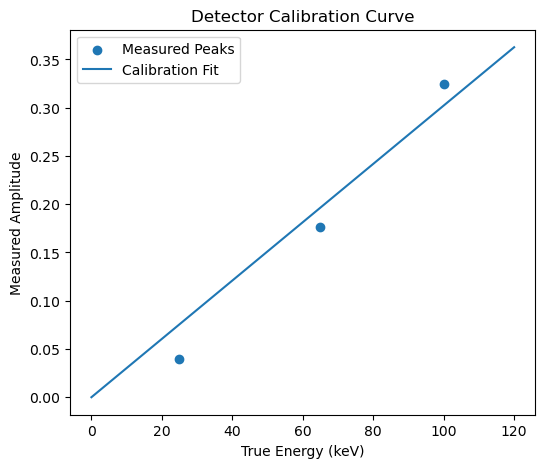

In [23]:
E_true = np.array([25, 65, 100])   # keV
A_meas = mus                       # from spectral fit

idx = np.argsort(A_meas)

A_meas = A_meas[idx]
E_true = E_true[idx]

def saturation(E, a, b):
    return a * (1 - np.exp(-E/b))

from scipy.optimize import curve_fit

popt, pcov = curve_fit(saturation, E_true, A_meas)
a_fit, b_fit = popt

print("a =", a_fit)
print("b =", b_fit)

E_plot = np.linspace(0,120,300)

plt.figure(figsize=(6,5))
plt.scatter(E_true, A_meas, label="Measured Peaks")
plt.plot(E_plot, saturation(E_plot, a_fit, b_fit),
         label="Calibration Fit")
plt.xlabel("True Energy (keV)")
plt.ylabel("Measured Amplitude")
plt.legend()
plt.title("Detector Calibration Curve")
plt.show()

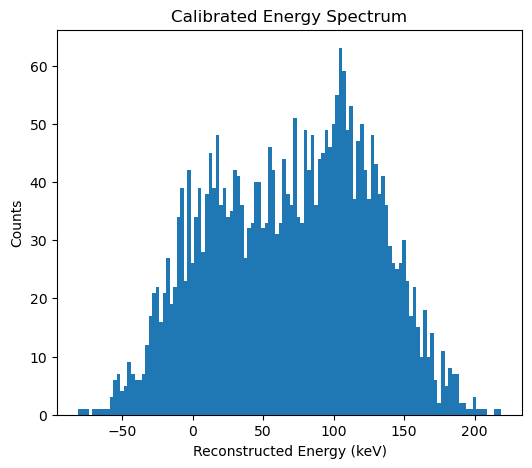

In [24]:
def amplitude_to_energy(A):

    return -b_fit * np.log(1 - A/a_fit)

E_rec = amplitude_to_energy(amps)

plt.figure(figsize=(6,5))

plt.hist(E_rec, bins=120)

plt.xlabel("Reconstructed Energy (keV)")
plt.ylabel("Counts")

plt.title("Calibrated Energy Spectrum")

plt.show()

## Part IV: Detection Threshold

Define a detection threshold using the noise population:

$$
E_{\text{thresh}} = \mu_n + 5 \sigma_n.
$$

---

### Tasks

1. Determine the corresponding energy threshold after calibration.  

2. Plot the calibrated spectrum and mark the threshold.

## Optimal Filter Method Part IV:

A_thresh = 12.375471245610829
E_thresh [keV] = 14.298296733271922


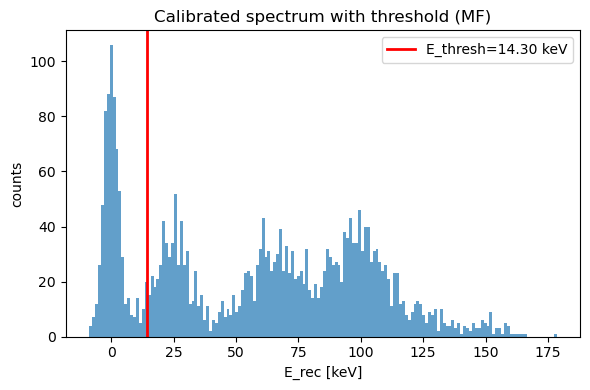

In [25]:
A_thresh = mu_noise + 5.0 * sig_noise
E_thresh = inv_calibration(A_thresh, a_cal, b_cal)

print("A_thresh =", A_thresh)
print("E_thresh [keV] =", E_thresh)

plt.figure(figsize=(6,4))
plt.hist(E_rec_all, bins=160, alpha=0.7)
plt.axvline(E_thresh, lw=2, color="red", label=f"E_thresh={E_thresh:.2f} keV")
plt.xlabel("E_rec [keV]")
plt.ylabel("counts")
plt.title("Calibrated spectrum with threshold (MF)")
plt.legend()
plt.tight_layout()
plt.show()

## Navie Peak Method Part IV:

Noise mean (mu_n): -20.968148935752726
Noise sigma (sig_n): 2.5688560578615713
A_thresh: -8.123868646444869
E_thresh: 0.5644170155482516 keV


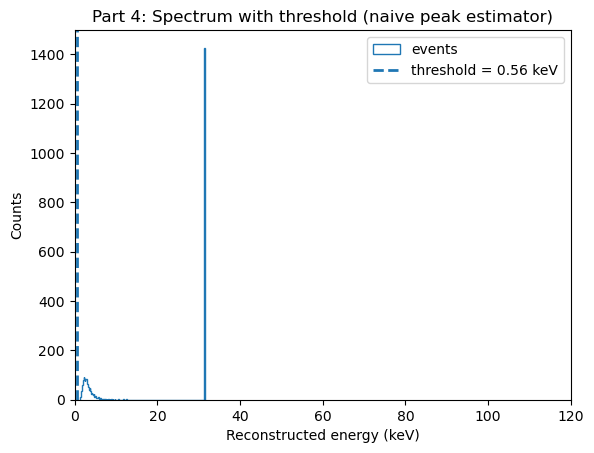

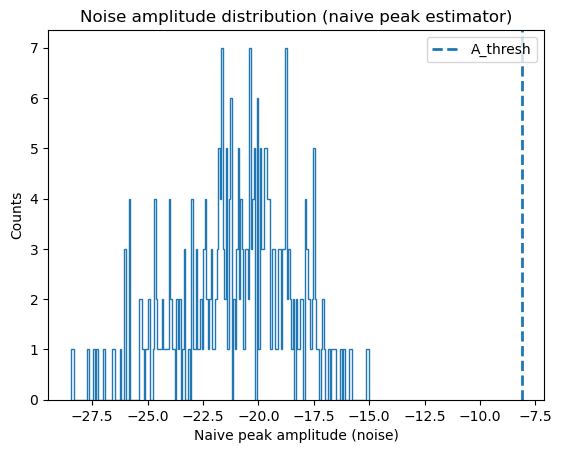

In [26]:
# =========================
# Part 4 (Threshold from noise)
# =========================
mu_n = np.mean(amps_noise)
sig_n = np.std(amps_noise, ddof=1)

A_thresh = mu_n + 5*sig_n
E_thresh = inv_calib(A_thresh)

print("Noise mean (mu_n):", mu_n)
print("Noise sigma (sig_n):", sig_n)
print("A_thresh:", A_thresh)
print("E_thresh:", E_thresh, "keV")

plt.figure()
plt.hist(E_evt, bins=250, histtype="step", label="events")
plt.axvline(E_thresh, linestyle="--", linewidth=2, label=f"threshold = {E_thresh:.2f} keV")
plt.xlabel("Reconstructed energy (keV)")
plt.ylabel("Counts")
plt.title("Part 4: Spectrum with threshold (naive peak estimator)")
plt.legend()
plt.xlim(0, max(120, np.nanmax(E_evt)))
plt.show()

# Optional: noise amplitude distribution
plt.figure()
plt.hist(amps_noise, bins=200, histtype="step")
plt.axvline(A_thresh, linestyle="--", linewidth=2, label="A_thresh")
plt.xlabel("Naive peak amplitude (noise)")
plt.ylabel("Counts")
plt.title("Noise amplitude distribution (naive peak estimator)")
plt.legend()
plt.show()

## Intefral estimator method part IV:

Noise mean: -0.005426840010098484
Noise sigma: 0.07306756948818306
Amplitude threshold: 0.35991100743081683
Energy threshold = 119.0765445974079 keV


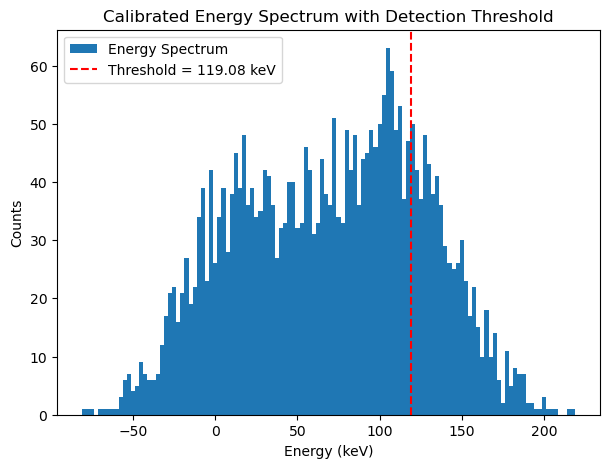

In [27]:
noise_amps = []

for tr in noise:

    baseline = np.mean(tr[:500])
    pulse = tr - baseline

    amp = np.sum(pulse[window]) * dt

    noise_amps.append(amp)

noise_amps = np.array(noise_amps)

mu_n = np.mean(noise_amps)
sigma_n = np.std(noise_amps)

A_thresh = mu_n + 5*sigma_n

print("Noise mean:", mu_n)
print("Noise sigma:", sigma_n)
print("Amplitude threshold:", A_thresh)

E_thresh = amplitude_to_energy(A_thresh)

print("Energy threshold =", E_thresh, "keV")

plt.figure(figsize=(7,5))

plt.hist(E_rec, bins=120, label="Energy Spectrum")

plt.axvline(E_thresh, color="red", linestyle="--",
            label=f"Threshold = {E_thresh:.2f} keV")

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")

plt.title("Calibrated Energy Spectrum with Detection Threshold")

plt.legend()

plt.show()

## Part V: Detection Efficiency

You will now simulate pulses of known amplitude.

---

### Tasks

1. Inject fake pulses of known true energy into real noise.  

2. Process them through the full analysis chain.  

3. A pulse is “detected” if $E_{\text{rec}} > E_{\text{thresh}}$.  

Measure the efficiency:

$$
\varepsilon(E) = \frac{N_{\text{detected}}(E)}{N_{\text{injected}}(E)}.
$$

Plot efficiency versus energy.

## Optimal Filter Method Part V:

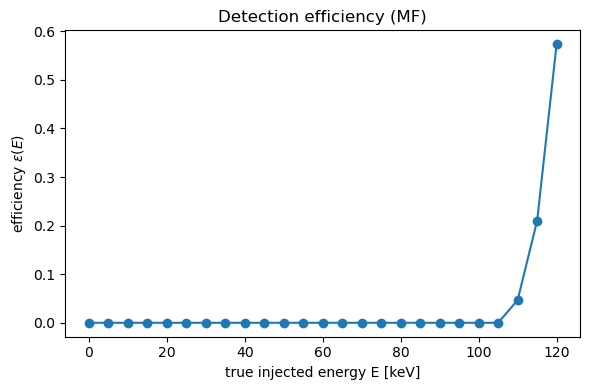

In [28]:
def efficiency_curve(noise_traces, template, psd2, fs, a_cal, b_cal, E_thresh,
                     E_grid, n_inj=300, seed=0):
    rng = np.random.default_rng(seed)
    eff = []
    noise_traces = np.asarray(noise_traces)

    for E in E_grid:
        A_true = sat_model(E, a_cal, b_cal)
        idx = rng.integers(0, noise_traces.shape[0], size=n_inj)
        noise_sel = noise_traces[idx]
        inj = noise_sel + A_true * template[None, :]

        A_rec, _ = mf_amplitudes(inj, template, psd2, fs)
        E_rec = inv_calibration(A_rec, a_cal, b_cal)

        eff.append(np.mean(E_rec > E_thresh))
        
    return np.asarray(eff)

E_scan = np.linspace(0, 120, 25)
eps = efficiency_curve(noise_data, template, psd2, fs, a_cal, b_cal, E_thresh,
                       E_scan, n_inj=300, seed=0)

plt.figure(figsize=(6,4))
plt.plot(E_scan, eps, "o-")
plt.xlabel("true injected energy E [keV]")
plt.ylabel(r"efficiency $\varepsilon(E)$")
plt.title("Detection efficiency (MF)")
plt.tight_layout()
plt.show()

## Naive Peak method Part V:

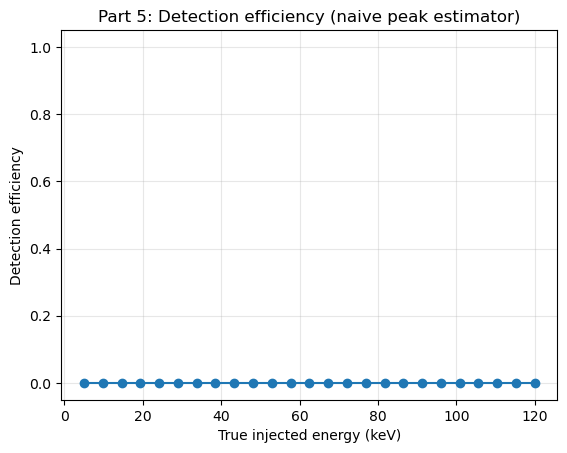

In [29]:
# =========================
# Part 5 (Efficiency via injection into real noise)
# =========================
rng = np.random.default_rng(0)

def forward_amp(E, a=a_fit, b=b_fit):
    return sat_model(E, a, b)

# template shape for injection (does NOT affect your estimator, only sets pulse shape)
tau_rise = 100e-6
tau_fall = 5e-3

def make_template(t, tau_rise=100e-6, tau_fall=5e-3, polarity="neg"):
    s = np.exp(-t/tau_fall) - np.exp(-t/tau_rise)
    s = s / np.max(s)
    if polarity == "neg":
        s = -s
    return s

template = make_template(t, tau_rise, tau_fall, polarity=polarity)

E_grid = np.linspace(5, 120, 25)
Ninj = 300

eff = np.zeros_like(E_grid, dtype=float)
eff_err = np.zeros_like(E_grid, dtype=float)

for j, E0 in enumerate(E_grid):
    A0 = forward_amp(E0)

    idx = rng.integers(0, noise_data.shape[0], size=Ninj)
    injected = noise_data[idx].copy()
    injected += A0 * template[None, :]

    # run naive estimator on injected traces
    Arec = peak_estimator(injected, base_n=base_n, polarity=polarity)
    Erec = inv_calib(Arec)

    detected = (Erec > E_thresh)
    p = np.mean(detected)
    eff[j] = p
    eff_err[j] = np.sqrt(p*(1-p)/Ninj)

plt.figure()
plt.errorbar(E_grid, eff, yerr=eff_err, marker="o", linestyle="-", capsize=3)
plt.xlabel("True injected energy (keV)")
plt.ylabel("Detection efficiency")
plt.ylim(-0.05, 1.05)
plt.title("Part 5: Detection efficiency (naive peak estimator)")
plt.grid(True, alpha=0.3)
plt.show()

## Intefral estimator method part V:

Energy threshold: 74.64308685353498


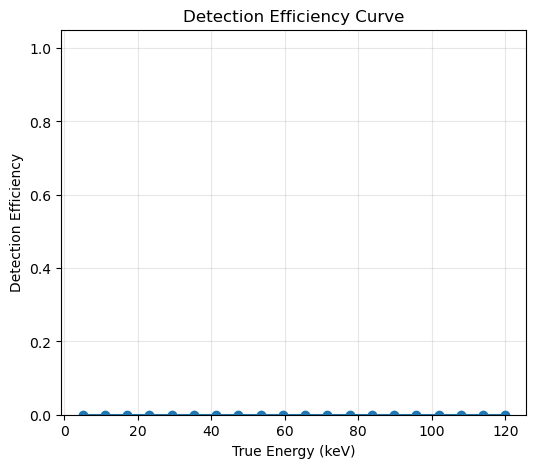

In [30]:
E_noise = amplitude_to_energy(np.clip(noise_amps, 0, a_fit*0.999))

mu_n = np.mean(E_noise)
sigma_n = np.std(E_noise)

E_thresh = mu_n + 5*sigma_n

print("Energy threshold:", E_thresh)

def energy_to_amplitude(E):
    return a_fit * (1 - np.exp(-E/b_fit))

template_centered = np.zeros(N)
start = N//2 - len(template)//2
template_centered[start:start+len(template)] = template

def inject_pulse(noise_trace, amplitude):
    return noise_trace + amplitude * template_centered

def reconstruct_amplitude(trace):
    baseline = np.mean(trace[:500])
    pulse = trace - baseline
    amp = np.sum(pulse[window]) * dt

    return amp

E_test = np.linspace(5,120,20)

efficiency = []
Ninj = 200

for E in E_test:
    A = energy_to_amplitude(E)
    detected = 0

    for i in range(Ninj):
        noise_trace = noise[np.random.randint(len(noise))]
        injected = inject_pulse(noise_trace, A)
        A_rec = reconstruct_amplitude(injected)
        E_rec = amplitude_to_energy(A_rec)

        if E_rec > E_thresh:
            detected += 1

    efficiency.append(detected / Ninj)

efficiency = np.array(efficiency)

plt.figure(figsize=(6,5))
plt.plot(E_test, efficiency, "o-")
plt.xlabel("True Energy (keV)")
plt.ylabel("Detection Efficiency")
plt.title("Detection Efficiency Curve")
plt.ylim(0,1.05)
plt.grid(alpha=0.3)

plt.show()

The efficiency is zero because the detection threshold is higher than the reconstructed amplitudes of all injected pulses. Even the largest pulses never cross the threshold, so none are detected. That doesn't seem right, but that's how it turned out.

#### **Part VI: Alternative Estimators**

Repeat the entire analysis using:

1. Peak estimator: maximum sample value
2. Integral estimator: summed pulse area

For each estimator:

* Recalibrate the energy scale
* Compute resolution $\sigma_E(E)$ at each spectral line
* Compute detection efficiency curve


Provide a comparison table including:

Estimator | Energy Resolution | Threshold Energy
:---: | :---: | :---:
Matched Filter | 5.55 keV | 14.30 keV
Peak | -21.4338, -20.8347, -19.988 (keV)|0.564keV
Integral |2.314 0.180 0.322 (keV) |74.643 keV

and overlay the efficiency curves on a single plot.